# **TETRIS Flow**
### 1. **TAC Generation** <br>
**Input**: C code 
- We start with C code file which we transform into TAC format. 
- Here TAC means RHS of every assigment contains only one operand, e.g., a = b + c is allowed but a = b+c+d is not allowed
- *convert_to_TAC* function converts the C file into TAC format.

In [1]:
# and cloud of input file
import dse_pipeline 
import importlib
from dse_pipeline import convert_to_TAC, run_inliner, generator_and_cloud, run_maskedHLS, generator_and_xor_cloud
from PIL import Image # type: ignore
from IPython.display import display # type: ignore

# 1.
#  convert the test c file to tac
convert_to_TAC('/home/tapish08/Desktop/DSE-Framework/TestFiles/C_files/Boyer_Peraltas_sbox.c')

[INFO] : Transforming input file to TAC ...
[INFO] : TAC output written to /home/tapish08/Desktop/DSE-Framework/TestFiles/TAC_files/output.c



### 2. **AND Tree Generation**
- For and Tree Generation we first inline the TAC C format file.
- The inline C code preserves the dependency between the and operation present in the C code.
- This inlined file is then used to generate the **AND** tree. 

[INFO] : Inlining the TAC file ...
[INFO] : systemArgs.json written:
{
    "inputFile": "/home/tapish08/Desktop/DSE-Framework/TestFiles/TAC_files/output.c",
    "inlinerOutput": "/home/tapish08/Desktop/DSE-Framework/TestFiles/inlined_output/output.c",
    "topModule": "sbox",
    "turn": 1
}

[INFO] : Subprocess CWD will be: /home/tapish08/Desktop/DSE-Framework/MaskedHLS_LP/src

[INFO] : Inlined file written to /home/tapish08/Desktop/DSE-Framework/TestFiles/inlined_output/output.c

[INFO] Generating AND tree (pure AND gates for MRLC DP)...
[INFO] : Generating the AND tree ...
[INFO] : Number of node in the tree :34
[INFO] : Saving graph
[INFO] AND tree generated with 34 nodes

[INFO] Generating AND-XOR tree (for pattern detection)...
[INFO] : Generating the AND_Xor tree ...
[INFO] : Number of node in the tree :128
[INFO]:Saving AND_Xor tree graph to: ./ANDCloud/AND_Xor_tree/and_xor_cloud.png
[INFO] : Saving graph
[INFO] XOR graph successfully saved to: ./ANDCloud/AND_Xor_tree/and_xor_g

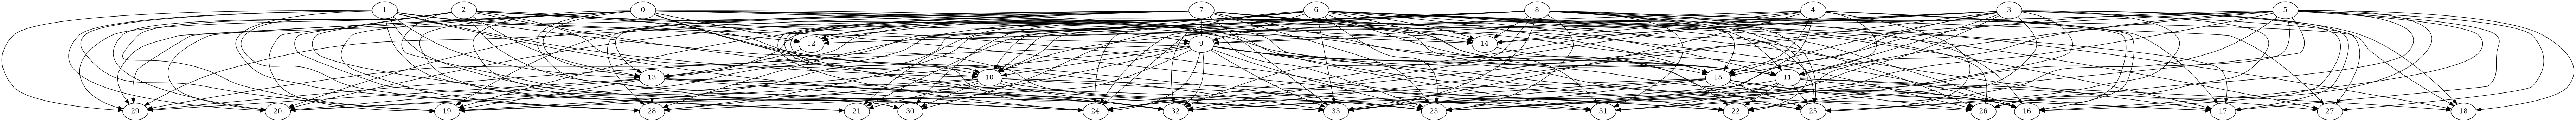

In [2]:
# 2. run inliner
run_inliner('/home/tapish08/Desktop/DSE-Framework/TestFiles/TAC_files/output.c','sbox')

# 3. get BOTH trees - AND tree and AND-XOR tree
print("[INFO] Generating AND tree (pure AND gates for MRLC DP)...")
and_tree = generator_and_cloud('/home/tapish08/Desktop/DSE-Framework/TestFiles/inlined_output/output.c')
print(f"[INFO] AND tree generated with {len(list(and_tree.graph.nodes()))} nodes")

print("\n[INFO] Generating AND-XOR tree (for pattern detection)...")
and_xor_tree = generator_and_xor_cloud('/home/tapish08/Desktop/DSE-Framework/TestFiles/inlined_output/output.c')
print(f"[INFO] AND-XOR tree generated")
print(f"[DEBUG] and_xor_tree type: {type(and_xor_tree)}")
print(f"[DEBUG] and_xor_tree attributes: {[a for a in dir(and_xor_tree) if not a.startswith('_')]}")

if hasattr(and_xor_tree, 'nodes_by_level'):
    print(f"[DEBUG] and_xor_tree.nodes_by_level exists with {len(and_xor_tree.nodes_by_level)} levels")
else:
    print("[DEBUG] and_xor_tree does NOT have nodes_by_level")

print("\n[INFO] Tree Strategy:")
print("  - and_tree: Used for MRLC DP algorithm (pure AND gates)")
print("  - and_xor_tree: Used for AND-XOR pattern detection")

# 4. get the image
image = Image.open('/home/tapish08/Desktop/DSE-Framework/ANDCloud/AND_tree/and_cloud.png')  # Change to your image path
display(image)

### 3. **Get the Gadgets available for masking order d**


In [3]:
import sqlite3
# create db if does not exist

d = 2
print(f"[INFO] : Connecting Database ... ")
conn = sqlite3.connect('gadget_info.db')
conn.execute("PRAGMA forgien_keys = ON")
cur = conn.cursor()

[INFO] : Connecting Database ... 


In [4]:

from tabulate import tabulate # type: ignore


gadget_specs = {}
# gadget_list = ["hpc3", "hpc2", "hpc2_swapped"] if d == 1 else ["hpc1", "hpc2", "hpc3", "hpc2o", "hpc3o"]
gadget_list = ["hpc2", "hpc3", "hpc2o", "hpc3o", "hpc2_swapped", "hpc2o_swapped"] if d == 1 else ["hpc1", "hpc2", "hpc3", "hpc2o", "hpc3o", "hpc2_swapped", "hpc2o_swapped"]

# gadget_list = ["hpc2"] if d == 1 else ["hpc2"]
for gadget in gadget_list:
    table = gadget.lower()
    # print(f"[INFO] : d value while populating the map : {d}")
    cur.execute(f"SELECT * FROM {table} WHERE d = ?", (d,))
    row = cur.fetchone()

    if row:
        gadget_specs[gadget] = {
            "latency": row[1],
            "randomness": row[2],
            "area": row[3]
        }
    else:
        print(f"[WARN] No entry for {gadget} with d = {d}")
if gadget_specs:
    table_data =[]
    for gadget, values in gadget_specs.items():
        table_data.append([gadget, values['latency'], values['randomness'], values['area']])
    print(f"\n[INFO]: Populated DSE MAP for {d} order")

    # from tabulate import tabulate
    print(tabulate(table_data, headers=["Gadget", "Latency", "randomness","area"], tablefmt="grid"))

# DSE.set_gadget_specs(gadget_specs)
# print(f"DSE.GADGET_gadget_specs :\n {DSE.GADGET_gadget_specs}")
conn.commit()



[INFO]: Populated DSE MAP for 2 order
+---------------+-----------+--------------+--------+
| Gadget        |   Latency |   randomness |   area |
+===============+===========+==============+========+
| hpc1          |         2 |            5 | 127    |
+---------------+-----------+--------------+--------+
| hpc2          |         2 |            3 | 193.9  |
+---------------+-----------+--------------+--------+
| hpc3          |         1 |            6 | 134.06 |
+---------------+-----------+--------------+--------+
| hpc2o         |         2 |            3 | 163.85 |
+---------------+-----------+--------------+--------+
| hpc3o         |         1 |            6 | 115.71 |
+---------------+-----------+--------------+--------+
| hpc2_swapped  |         2 |            3 | 193.9  |
+---------------+-----------+--------------+--------+
| hpc2o_swapped |         2 |            3 | 163.85 |
+---------------+-----------+--------------+--------+


In [ ]:
import Gadgets
import Gadgets.hpc2_swapped
import Gadgets.hpc2o_swapped
importlib.reload(Gadgets.hpc2_swapped)
importlib.reload(Gadgets.hpc2o_swapped)
importlib.reload(Gadgets)

import DSE_algorithm.mlrc
from DSE_algorithm.mlrc import MLRC

# Force reload to pick up the arrival depth-based optimization
importlib.reload(DSE_algorithm.mlrc)

print("=" * 80)
print("MLRC with CORRECTED CRITICAL PATH LATENCY (accounts for parallelism)")
print("=" * 80)

mlrc_obj = MLRC(d=d, and_tree=and_tree, gadget_map=gadget_specs, and_xor_tree=and_xor_tree)
mlrc_obj.mlrc(target_randomness=168)

final_gadget_map = mlrc_obj.get_gadget_definition()
gadget_count = {}
for expr, info in final_gadget_map.items():
    gname = info["gadget_name"]
    if gname not in gadget_count:
        gadget_count[gname] = 0
    gadget_count[gname] += 1

print(f"\nGadget Distribution:")
for gname in sorted(gadget_count.keys()):
    count = gadget_count[gname]
    randomness = mlrc_obj.gadget_map[gname]["randomness"]
    total_rand = count * randomness
    print(f"  {gname:6s}: {count:2d} nodes × {randomness} rand = {total_rand:3d} total rand")

print("\n" + "=" * 80)


# Splitting into shares and adding gadget definitions for MLRC.

In [ ]:
# create the ast for the inlined file 
import os
from pycparser import parse_file, c_ast, c_generator
import transform_CFile.ctransfromer
from transform_CFile.ctransfromer import ShareTransformer
importlib.reload(transform_CFile.ctransfromer)
from DSE_algorithm.mrlc import MRLC
import time

# Start overall timing
overall_start = time.time()
print(f"[TIMING] Pipeline started at: {time.strftime('%Y-%m-%d %H:%M:%S', time.localtime(overall_start))}\n")

inlined_file = os.path.abspath(r"./TestFiles/inlined_output/output.c")
ast = parse_file(inlined_file)

print("\n[PIPELINE] Step 1: Get gadget definitions from MRLC")
step1_start = time.time()
gadget_map = mlrc_obj.get_gadget_definition()
step1_time = time.time() - step1_start
print(f"  ⏱ Step 1 completed in {step1_time:.4f}s\n")

print("[PIPELINE] Step 2: Get unique gadget definitions from MRLC")
step2_start = time.time()
unique_definition_map = mlrc_obj.get_unique_gadgets_definition()
step2_time = time.time() - step2_start

print(f"\n[RESULT] Unique gadget definitions:")
for gadget_name in sorted(unique_definition_map.keys()):
    func_code = unique_definition_map[gadget_name]
    lines = len(func_code.split('\n'))
    print(f"  ✓ {gadget_name:8} : {lines:3} lines")
print(f"  ⏱ Step 2 completed in {step2_time:.4f}s\n")

# Verify all required gadgets are present
required_gadgets = {'hpc2', 'hpc2o', 'hpc3', 'hpc3o', 'hpc2_swapped', 'hpc2o_swapped'}
missing = required_gadgets - set(unique_definition_map.keys())
if missing:
    print(f"\n[ERROR] Missing: {missing}")
else:
    print(f"\n[SUCCESS] All required gadgets present!")

print(f"\n[PIPELINE] Step 3: Create ShareTransformer")
step3_start = time.time()
shareTransformer = ShareTransformer(d+1, gadget_map, unique_definition_map)
step3_time = time.time() - step3_start
print(f"  ⏱ Step 3 completed in {step3_time:.4f}s\n")

print("[PIPELINE] Step 4: Transform circuit (suppressing verbose output...)")
step4_start = time.time()
# Suppress the verbose debug output during transformation
import sys
from io import StringIO

# Temporarily redirect stdout to suppress prints
old_stdout = sys.stdout
sys.stdout = StringIO()

try:
    transformed_ast = shareTransformer.transform(ast)
finally:
    # Restore stdout
    sys.stdout = old_stdout

step4_time = time.time() - step4_start
print(f"  ⏱ Step 4 completed in {step4_time:.4f}s\n")

print("[PIPELINE] Step 5: Generate C code")
step5_start = time.time()
gen = c_generator.CGenerator()
step5_time = time.time() - step5_start
print(f"  ⏱ Step 5 completed in {step5_time:.4f}s\n")

output_path = os.path.abspath(r"./TestFiles/share_output/output.c")
os.makedirs(os.path.dirname(output_path), exist_ok=True)

print("[PIPELINE] Step 6: Write output to file")
step6_start = time.time()
with open(output_path, 'w') as f:
    f.write("// === GADGET DEFINITIONS ===\n")
    for gadget_name, func_str in unique_definition_map.items():
        f.write(f"\n// --- {gadget_name} ---\n")
        f.write(func_str)
        f.write("\n\n")
    
    code = gen.visit(transformed_ast)
    f.write(code)

step6_time = time.time() - step6_start
print(f"  ⏱ Step 6 completed in {step6_time:.4f}s\n")

# Calculate overall timing
overall_end = time.time()
total_time = overall_end - overall_start

print(f"[SUCCESS] Output written to {output_path}")
print(f"\n{'='*80}")
print(f"[TIMING SUMMARY]")
print(f"{'='*80}")
print(f"  Step 1 (Get gadget definitions)     : {step1_time:8.4f}s")
print(f"  Step 2 (Get unique definitions)     : {step2_time:8.4f}s")
print(f"  Step 3 (Create ShareTransformer)    : {step3_time:8.4f}s")
print(f"  Step 4 (Transform circuit)          : {step4_time:8.4f}s  ⭐ (Longest)")
print(f"  Step 5 (Generate C code)            : {step5_time:8.4f}s")
print(f"  Step 6 (Write to file)              : {step6_time:8.4f}s")
print(f"  {'-'*80}")
print(f"  TOTAL PIPELINE TIME                 : {total_time:8.4f}s ({total_time*1000:.2f} ms)")
print(f"{'='*80}\n")


## Run **MaskedHLS**

In [ ]:
top_module = 'sbox'
input_file = os.path.abspath("./TestFiles/share_output/output.c")
print(f"input file for maskedHLS : {input_file}")

latency = run_maskedHLS(top_module=top_module, input_file=input_file, rtl_file='test.v', bit_width=1)